# Hamiltonian Simulation with Generalized Quantum Signal Processing (GQSP)

> **Simulating physical and chemical systems** was among the original motivations for quantum computing, as first envisioned by Richard Feynman in 1982, and remains one of its most impactful applications. Time-independent Hamiltonian simulation refers to the task of approximately implementing the unitary evolution operator $e^{-iHt}$ for a Hermitian matrix $H$. When access to the Hamiltonian is provided via block-encoding, this can be realized by applying an appropriate polynomial transformation within a desired precision $\epsilon$.
>
> **Generalized Quantum Signal Processing (GQSP)** [<a href="#ref-gqsp">1</a>] achieves this by applying a Laurent polynomial $P(W)$ to the walk operator $W$ of the block-encoded Hamiltonian. The polynomial coefficients are derived from the [Jacobi–Anger expansion](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb) (Eq. (1): $e^{it\cos(x)} = \sum_k i^k J_k(t)\,e^{ikx}$). GQSP requires only **one auxiliary qubit** and eliminates the need for amplitude amplification.
>
> - **Input:** A Hermitian operator $H$ given through a block-encoding unitary $U_H$ with scaling factor $\alpha \ge \|H\|$, evolution time $t$, and target error $\epsilon$.
> - **Output:** A unitary $U$ approximating $e^{-iHt}$, with $\|U - e^{-iHt}\| < \epsilon$.
>
> **Complexity:** $O\!\left(\alpha t + \frac{\log \epsilon^{-1}}{\log\!\left(e + \log(\epsilon^{-1}) / \alpha t\right)}\right)$ calls to the block-encoding, using one auxiliary qubit and a classical preprocessing step to compute the GQSP rotation angles.
>
> ---
>
> **Keywords:** Hamiltonian Simulation, Block Encoding, Generalized Quantum Signal Processing, GQSP, Walk Operator, Oracle/Query complexity.

A block-encoded Hamiltonian refers to its embedding within a larger unitary matrix.

**Definition**: A $(s, m, \epsilon)$-encoding of a $2^n\times 2^n$ matrix $A$ refers to completing it into a $2^{n+m}\times 2^{n+m}$ unitary matrix $U_{(s,m,\epsilon)-A}$:
$$
U_{(s,m,\epsilon)-A} = \begin{pmatrix} A/s & * \\ * & * \end{pmatrix},
$$
with functional error $\left|\left|\left(U_{(s,m,\epsilon)-A}\right)_{0:2^n-1,0:2^n-1}-A/s \right|\right|\leq \epsilon$. Here $s$ is a scaling factor that ensures the overall operator is unitary, $m$ is the number of auxiliary (block) qubits, and $\epsilon$ is the encoding error.

This notebook assumes basic knowledge of Linear Combination of Unitaries (LCU); see the [LCU tutorial](https://github.com/Classiq/classiq-library/blob/main/tutorials/basic_tutorials/quantum_primitives/linear_combination_of_unitaries/linear_combination_of_unitaries.ipynb) for background.

The [GQSP](https://github.com/Classiq/classiq-library/blob/main/algorithms/quantum_primitives/gqsp/gqsp.ipynb) approach implements polynomials on unitary operators.
For Hamiltonian evolution, given an exact $(s, m, 0)$-encoding of the Hamiltonian (denoting $U_H \equiv U_{(s,m,0)-H}$), we define the Szegedy quantum walk operator [<a href="#ref-szegedy">2</a>] $W \equiv \Pi_{|0\rangle_m}\, U_H$, where $\Pi_{|0\rangle_m}$ reflects about the $|0\rangle$ state of the block variable. The walk operator $W$ is unitary, with eigenvalues $z = e^{\pm i\arccos(\lambda/s)}$, where $\lambda$ are the Hamiltonian eigenvalues. By the [Jacobi–Anger expansion](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb) ([Eq. (1)](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb)), the polynomial approximating $e^{-ist\cos(x)}$ as a Laurent series in $z = e^{ix}$ gives $P(z) \approx e^{-i\lambda t}$ on the eigenvalue $z = e^{i\arccos(\lambda/s)}$ (since $\cos(x) = \lambda/s$) — the desired time-evolution phase. Applying $P(W)$ via GQSP therefore gives approximately $e^{-iHt}$ in the block.

GQSP computes a set of single-qubit rotation angles $\{\phi_k\}$ such that the resulting circuit block-encodes the desired polynomial:
$$
\mathrm{GQSP}(W) \approx U_{(1,\,m+1,\,\epsilon)-e^{-iHt}} = \begin{pmatrix} e^{-iHt} & * \\ * & * \end{pmatrix}.
$$

(In practice, our prefactor is slightly different, $\beta^{-1}$ with $\beta = 0.9999$ which ensures numerical stability of the classical angle computation).

Compared the the QSVT approach for Hamiltonian simulation, the GQSP method uses only one extra block qubit, and requires no amplitude amplification. However, it includes controlled operations on the block-encoding unitary.

**<div class="alert alert-success">This notebook demonstrates Hamiltonian simulation using the GQSP method. For the other approaches, see the companion notebooks on <a href="https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb">QSVT</a> and <a href="https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb">Qubitization</a>. For a side-by-side <a href="#Comparison-with-Other-Methods">comparison of all three methods</a>, see the table at the end of this notebook.</div>**

## Preliminaries

### Setting a Specific Hamiltonian to Evolve

We set some specific hyperparameters for our problem. We use a simple Hamiltonian given as a sum of Pauli strings, and the `lcu_pauli` function to block-encode it via the Linear Combination of Unitaries (LCU) technique:
$$
H = \sum_{i} \alpha_i U_i, \qquad U_{(\bar{\alpha},m,0)-H} = \begin{pmatrix} H/\bar{\alpha} & * \\ * & * \end{pmatrix}, \qquad \bar{\alpha} = \sum_i |\alpha_i|.
$$

*To treat different problems with the same algorithm, simply change theses hyperparameters*.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy

from classiq import *

In [2]:
EVOLUTION_TIME = 22
EPS = 1e-7

HAMILTONIAN = (
    0.4 * Pauli.I(0)
    + 0.1 * Pauli.Z(1)
    + 0.05 * Pauli.X(0) * Pauli.X(1)
    + 0.2 * Pauli.Z(0) * Pauli.Z(1)
)
print(f"The Hamiltonian to evolve: {HAMILTONIAN}")

The Hamiltonian to evolve: 0.4 + 0.05*Pauli.X(0)*Pauli.X(1) + 0.2*Pauli.Z(0)*Pauli.Z(1) + 0.1*Pauli.Z(1)


Next, we define the block-encoding quantum function, and a Quantum Struct for its variable.

In [3]:
data_size = HAMILTONIAN.num_qubits
block_size = (
    (len(HAMILTONIAN.terms) - 1).bit_length() if len(HAMILTONIAN.terms) != 1 else 1
)
BE_SCALING = np.sum(
    np.abs([term.coefficient for term in HAMILTONIAN.terms])
)  # scaling for LCU of Paulis

print(f"Block size: {block_size}")
print(f"Block-encoding scaling factor: {BE_SCALING}")


class BlockEncodedState(QStruct):
    data: QNum[data_size]
    block: QNum[block_size]


@qfunc
def be_hamiltonian(state: BlockEncodedState):
    lcu_pauli(HAMILTONIAN * (1 / BE_SCALING), state.data, state.block)

Block size: 2
Block-encoding scaling factor: 0.75


Finally, we set the initial state to evolve and calculate classically the expected evolved state for verifying the quantum methods.

In [4]:
state_to_evolve = np.random.rand(2**data_size)
state_to_evolve = (state_to_evolve / np.linalg.norm(state_to_evolve)).tolist()
matrix = pauli_operator_to_matrix(HAMILTONIAN)
expected_state = scipy.linalg.expm(-1j * matrix * EVOLUTION_TIME) @ state_to_evolve

### Setting Up a Statevector Simulator

Working with block-encoding typically requires post-selection of the block variable being at state $|0\rangle$. The success of this process can be amplified via Oblivious Amplitude Amplification. In this notebook, instead, we use a statevector simulator and project the result. We import two utility functions from `hamiltonian_simulation_utils`:
- `get_projected_state_vector`: extracts the post-selected statevector from the execution results.
- `compare_quantum_classical_states`: aligns the global phase and computes the overlap with the classically computed reference.

In [5]:
from hamiltonian_simulation_utils import (
    compare_quantum_classical_states,
    get_projected_state_vector,
)

execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

### The Jacobi–Anger Expansion

The polynomial approximation of the time evolution relies on the [Jacobi–Anger expansion](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/jacobi_anger_expansion.ipynb). For GQSP, we use the complex exponential form $e^{it\cos(x)} = \sum_k i^k J_k(t)\,e^{ikx}$, implemented via `poly_jacobi_anger_exp_cos`. We then compute the GQSP rotation angles from this polynomial using `gqsp_phases`.

In [6]:
from classiq.applications.qsp.qsp import (
    gqsp_phases,
    poly_jacobi_anger_degree,
    poly_jacobi_anger_exp_cos,
)

GQSP_SCALE = 0.9999
t0 = time.perf_counter()
gqsp_degree = poly_jacobi_anger_degree(EPS, EVOLUTION_TIME * BE_SCALING)

jacobi_anger_poly_expcos = GQSP_SCALE * poly_jacobi_anger_exp_cos(
    gqsp_degree, -EVOLUTION_TIME * BE_SCALING
)
jacobi_anger_phases_expcos = gqsp_phases(jacobi_anger_poly_expcos)
classical_preprocess_time_gqsp = time.perf_counter() - t0
print(f"GQSP polynomial degree: {gqsp_degree}")
print(f"Classical preprocessing time: {classical_preprocess_time_gqsp:.3f} s")

GQSP polynomial degree: 33
Classical preprocessing time: 2.932 s


### The Walk Operator

> **Note:** The current implementation assumes that the block-encoding unitary $U_H$ is also Hermitian. For the non-Hermitian generalization, see the Technical Notes.

Given the block-encoding $U_{(s,m,0)-H}$, we define the Szegedy quantum walk operator [<a href="#ref-szegedy">2</a>]:
$$
W \equiv \Pi_{|0\rangle_m}\, U_{(s,m,0)-H},
$$
where $\Pi_{|0\rangle_m}$ is a reflection about the $|0\rangle$ state of the block variable. As mentioned above, it has the key property that its spectrum is directly tied to the Hamiltonian's eigenvalues:
$$
\text{eigenvalues: } e^{\pm i \arccos(\lambda/s)}, \quad \text{eigenvectors: } |\varphi^{\pm}_{\lambda}\rangle \equiv \frac{1}{\sqrt{2}}\left(|v_{\lambda}\rangle|0\rangle_m \pm i|\perp_{\lambda}\rangle\right),
$$
where $|v_\lambda\rangle$ is an eigenstate of $H$ with eigenvalue $\lambda$.

In [7]:
from classiq.qmod.symbolic import pi


@qfunc
def my_reflect_about_zero(qba: QNum):
    control(qba == 0, lambda: phase(pi))
    phase(pi)


@qfunc
def walk_operator(
    be_qfunc: QCallable[BlockEncodedState], state: BlockEncodedState
) -> None:
    be_qfunc(state)
    my_reflect_about_zero(state.block)

### Verifying the Block-Encoding

As a sanity check before the main algorithm, we verify the Hamiltonian block-encoding: we apply $U_H$ on the initial state and check that the post-selected result matches $(H/\bar{\alpha})|\psi\rangle$ as expected.

In [8]:
@qfunc
def main(data: Output[QNum[data_size]], block: Output[QNum[block_size]]):
    state = BlockEncodedState()
    allocate(state)

    inplace_prepare_amplitudes(state_to_evolve, 0.0, state.data)
    be_hamiltonian(state)
    bind(state, [data, block])


qprog_be = synthesize(main)
show(qprog_be)

Quantum program link: https://platform.classiq.io/circuit/3D33qBTW7qLuxJGlgJOoBiBBhwH


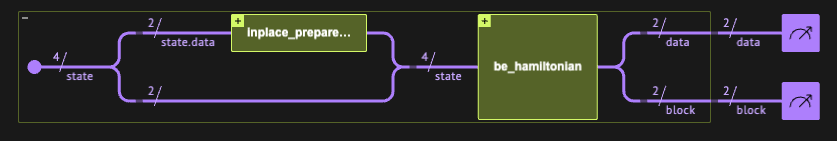

In [9]:
TOLERANCE = 1e-9
with ExecutionSession(qprog_be, execution_preferences=execution_preferences) as es:
    res_be = es.sample()

state_result_be = get_projected_state_vector(res_be)
expected_state_be = matrix @ state_to_evolve

renormalized_be, overlap_be = compare_quantum_classical_states(
    expected_state_be, state_result_be, BE_SCALING
)
print("Expected state:", expected_state_be)
print("Resulting state after rescaling:", renormalized_be)
assert np.isclose(overlap_be, 1, TOLERANCE)
print("=" * 40)
print(f"Fidelity is 1 (with {TOLERANCE} tolerance)")

Expected state: [0.62080558+0.j 0.09074939+0.j 0.04500028+0.j 0.18596617+0.j]
Resulting state after rescaling: [0.62080558+2.44087822e-18j 0.09074939-9.63604777e-17j
 0.04500028-2.02041677e-16j 0.18596617-1.14021062e-16j]
Fidelity is 1 (with 1e-09 tolerance)


## Implementation

We define a Quantum Struct for the GQSP block-encoding. The GQSP method adds one block qubit (`block_gqsp`) to the Hamiltonian block variable (`block_ham`). The data variable follows that of the Hamiltonian encoding.

Applying GQSP requires a *negative power* of the walk operator, since the approximating polynomial $P(z)$ is a Laurent polynomial that includes negative powers of $z$ (corresponding to $W^{-1}$). This is handled by the `negative_power` parameter.

In [10]:
class GQSPBlock(QStruct):
    block_ham: QNum[block_size]
    block_gqsp: QBit


class GQSPState(QStruct):
    data: QNum[data_size]
    block: GQSPBlock


@qfunc
def gqsp_hamiltonian_evolution(
    be_qfunc: QCallable[BlockEncodedState],
    state: GQSPState,
):
    gqsp(
        u=lambda: walk_operator(be_qfunc, [state.data, state.block.block_ham]),
        aux=state.block.block_gqsp,
        phases=jacobi_anger_phases_expcos,
        negative_power=gqsp_degree,
    )

The code in the rest of this section builds a model that applies the `gqsp_hamiltonian_evolution` function on the randomly prepared vector, synthesizes it, executes the resulting quantum program, and verifies the results.

In [11]:
@qfunc
def main(data: Output[QNum[data_size]], block: Output[QNum[block_size + 1]]):
    state = GQSPState()
    allocate(state)

    inplace_prepare_amplitudes(state_to_evolve, 0.0, state.data)
    gqsp_hamiltonian_evolution(be_hamiltonian, state)
    bind(state, [data, block])


qprog_gqsp = synthesize(main)
show(qprog_gqsp)

Quantum program link: https://platform.classiq.io/circuit/3D33t06StqkU0O0rBRxsTEFVZF4


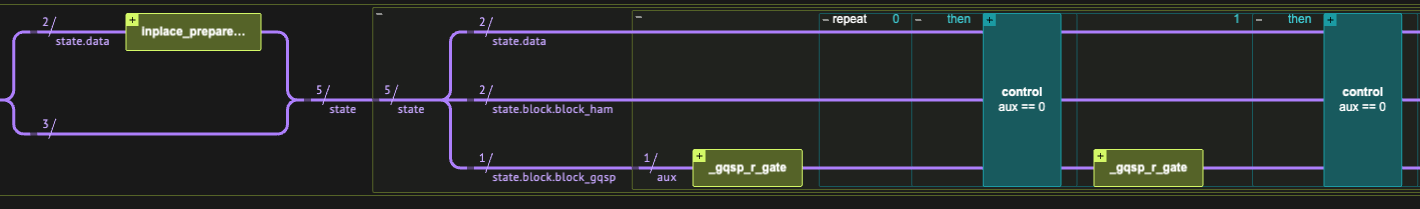

In [12]:
with ExecutionSession(qprog_gqsp, execution_preferences) as es:
    result_gqsp = es.sample()

state_result_gqsp = get_projected_state_vector(result_gqsp)
exp_scaling_factor_gqsp = 1 / GQSP_SCALE

In [13]:
renormalized_state_gqsp, overlap_gqsp = compare_quantum_classical_states(
    expected_state, state_result_gqsp, exp_scaling_factor_gqsp
)
print("Expected state:", expected_state)
print("Resulting state after rescaling:", renormalized_state_gqsp)
assert np.linalg.norm(renormalized_state_gqsp - expected_state) < EPS
print("=" * 40)
print("Overlap between expected and resulting state:", overlap_gqsp)

Expected state: [-0.87895119-0.0601642j   0.2797734 -0.11212048j -0.03050629-0.27574903j
 -0.22787636+0.06391499j]
Resulting state after rescaling: [-0.87895119-0.0601642j   0.27977341-0.11212048j -0.03050629-0.27574903j
 -0.22787636+0.06391499j]
Overlap between expected and resulting state: 1.0000000000000002


## References

<a id='ref-gqsp'>[1]</a>: [Motlagh, D., and Wiebe, N. *Generalized quantum signal processing.* PRX Quantum **5**, 020368 (2024).](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.5.020368)

<a id='ref-szegedy'>[2]</a>: [Szegedy, M. *Quantum speed-up of Markov chain based algorithms.* In *45th Annual IEEE Symposium on Foundations of Computer Science*, pp. 32–41 (2004).](https://ieeexplore.ieee.org/abstract/document/1366222)

<a id='ref-lin'>[3]</a>: [Lin, L. *Lecture notes on quantum algorithms for scientific computation.* arXiv:2201.08309 [quant-ph] (2022).](https://arxiv.org/abs/2201.08309)

## Technical Notes

### Generalizing to Non-Hermitian Block-Encoding Unitaries

The current implementation assumes that the block-encoding unitary $U_H$ is also Hermitian. This assumption underlies the walk operator's spectral properties. For a non-Hermitian block-encoding unitary, an analogous walk operator can be defined as $\tilde{W} \equiv U_H^T \Pi_{|0\rangle_m} U_H \Pi_{|0\rangle_m}$, which satisfies equivalent spectral properties. See Section 7.4 in Ref. [<a href="#ref-lin">3</a>] for details.

### Comparison with Other Methods

| Method | extra block qubits | Controlled $U_H$? | Amplitude amplification? | Classical preprocessing |
|---|---|---|---|---|
| [GQSP](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_gqsp.ipynb) | 1 | Yes | No | Angle computation |
| [QSVT](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qsvt.ipynb) | 2 | No | Yes (for a factor of 2) | Angle computation |
| [Qubitization](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_qubitization.ipynb) | $O(\log d)$ | Yes | Yes (for the sum of Cheb. coefficients) | None |

All three methods share the same asymptotic query complexity. Differences in the table reflect the detailed implementation of this specific example.